# Détection de faux billets — ONCFM
**Josy Elices-Diez** | Juin 2026

Objectif : classer les billets en vrais / faux à partir de 6 mesures physiques, en comparant 4 algorithmes et en sélectionnant le meilleur sur le critère recall(False).

## 1. Configuration et chargement

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

RANDOM_STATE = 42
FIGURES_DIR = 'figures/'

import os
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
df = pd.read_csv('data_raw/billets.csv', sep=';')
print(f'Dimensions : {df.shape}')
df.head()

Dimensions : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [3]:
print(df.dtypes)
print()
print('Valeurs uniques is_genuine :', df['is_genuine'].unique())

is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

Valeurs uniques is_genuine : [ True False]


## 2. Exploration des données (EDA)

In [4]:
print('Distribution de la variable cible :')
print(df['is_genuine'].value_counts())
print()
print('Ratio :', df['is_genuine'].value_counts().to_dict())

Distribution de la variable cible :
is_genuine
True     1000
False     500
Name: count, dtype: int64

Ratio : {True: 1000, False: 500}


In [5]:
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

Valeurs manquantes par colonne :
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


In [6]:
features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
print('Statistiques descriptives par classe :')
df.groupby('is_genuine')[features].describe().T

Statistiques descriptives par classe :


is_genuine               False        True 
diagonal     count  500.000000  1000.000000
             mean   171.901160   171.987080
             std      0.306861     0.300441
             min    171.040000   171.040000
             25%    171.690000   171.790000
             50%    171.910000   171.990000
             75%    172.092500   172.200000
             max    173.010000   172.920000
height_left  count  500.000000  1000.000000
             mean   104.190340   103.949130
             std      0.223758     0.300231
             min    103.510000   103.140000
             25%    104.040000   103.740000
             50%    104.180000   103.950000
             75%    104.332500   104.140000
             max    104.880000   104.860000
height_right count  500.000000  1000.000000
             mean   104.143620   103.808650
             std      0.270878     0.291570
             min    103.430000   102.820000
             25%    103.950000   103.610000
             50%    104.160000   103.810000
             75%    104.320000   104.000000
             max    104.950000   104.950000
margin_low   count  492.000000   971.000000
             mean     5.215935     4.116097
             std      0.553531     0.319124
             min      3.820000     2.980000
             25%      4.840000     3.905000
             50%      5.190000     4.110000
             75%      5.592500     4.340000
             max      6.900000     5.040000
margin_up    count  500.000000  1000.000000
             mean     3.350160     3.052130
             std      0.180498     0.186340
             min      2.920000     2.270000
             25%      3.220000     2.930000
             50%      3.350000     3.050000
             75%      3.472500     3.180000
             max      3.910000     3.740000
length       count  500.000000  1000.000000
             mean   111.630640   113.202430
             std      0.615543     0.359552
             min    109.490000   111.760000
             25%    111.200000   112.950000
             50%    111.630000   113.205000
             75%    112.030000   113.460000
             max    113.850000   114.440000

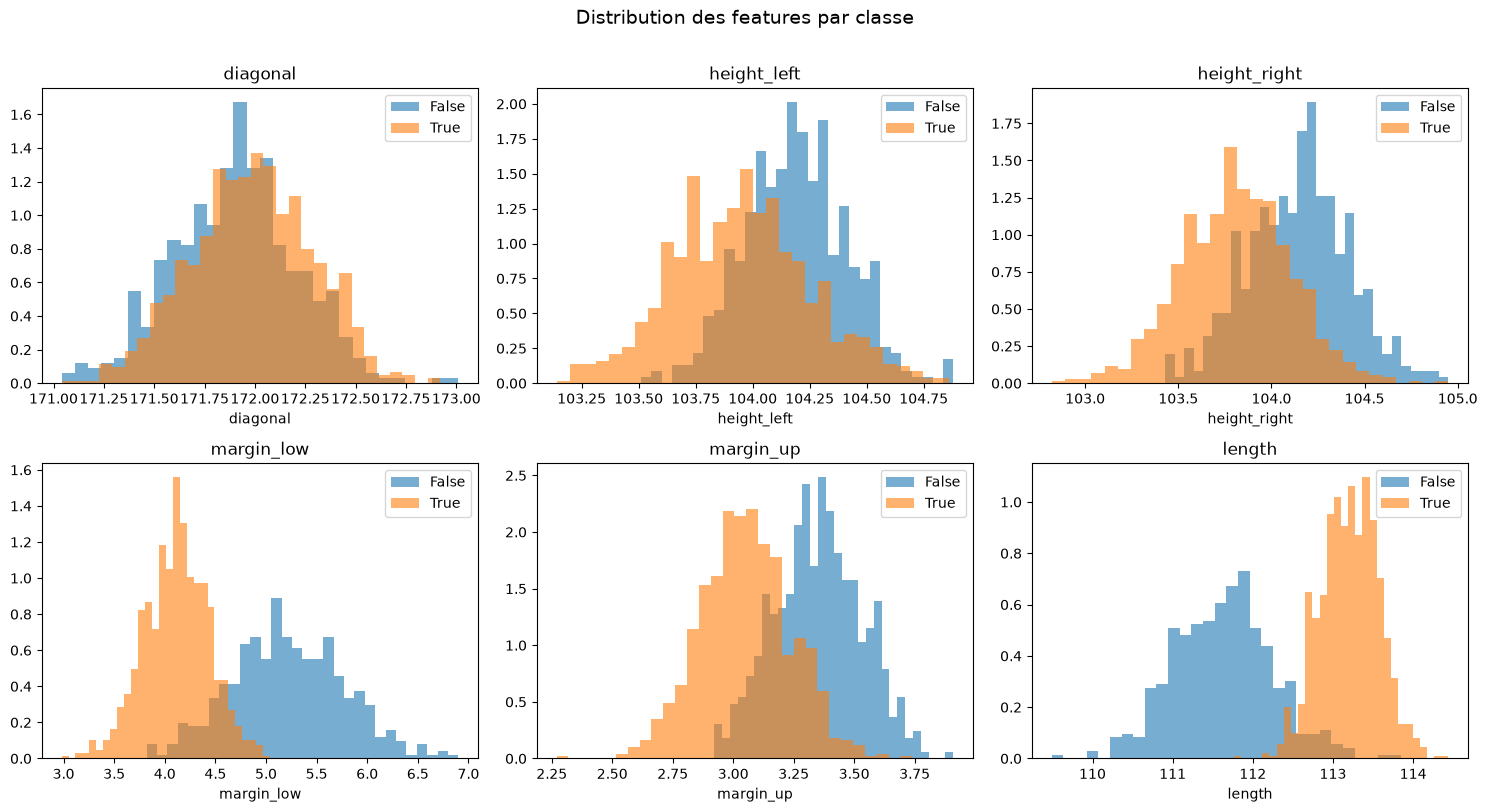

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for label, group in df.groupby('is_genuine'):
        axes[i].hist(group[col].dropna(), bins=30, alpha=0.6,
                     label=str(label), density=True)
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].set_xlabel(col)

plt.suptitle('Distribution des features par classe', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}distributions.png', dpi=120, bbox_inches='tight')
plt.show()

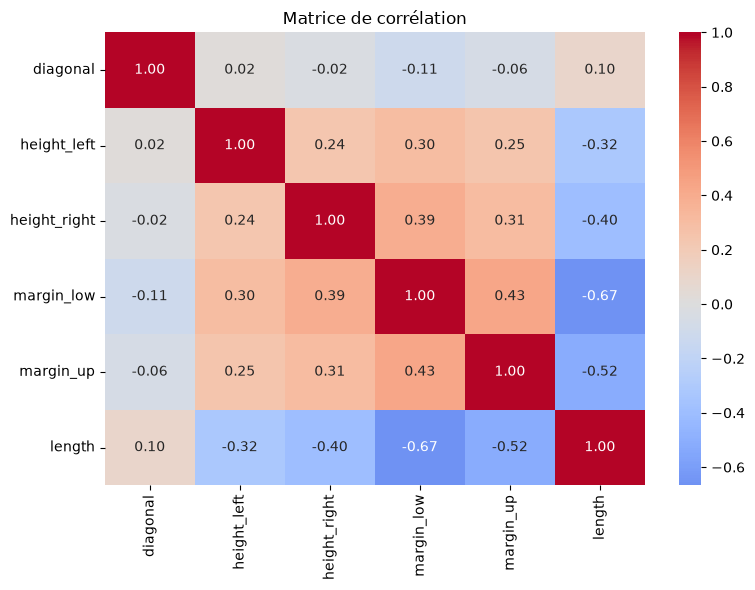

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}correlation.png', dpi=120, bbox_inches='tight')
plt.show()

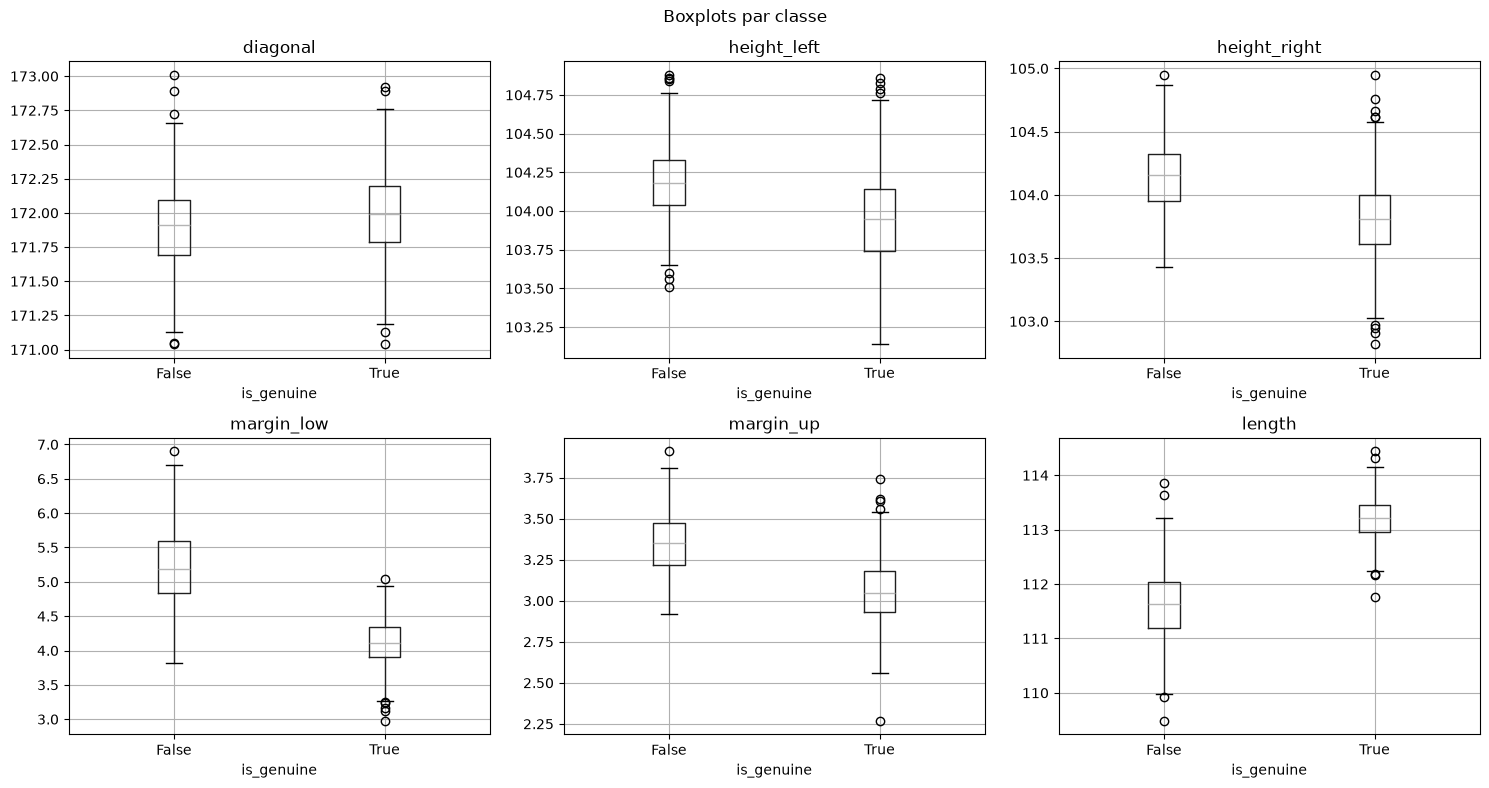

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='is_genuine', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('is_genuine')

plt.suptitle('Boxplots par classe')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [10]:
df2 = df.copy()
df2['is_genuine'] = df2['is_genuine'].map({True: 1, False: 0, 'True': 1, 'False': 0})
print('Encodage is_genuine :', df2['is_genuine'].value_counts().to_dict())

Encodage is_genuine : {1: 1000, 0: 500}


In [11]:
missing_idx = df2['margin_low'].isnull()
print(f'Lignes avec margin_low manquant : {missing_idx.sum()}')

imputer_features = ['diagonal', 'height_left', 'height_right', 'margin_up', 'length']

X_imp_train = df2.loc[~missing_idx, imputer_features]
y_imp_train = df2.loc[~missing_idx, 'margin_low']
X_imp_pred  = df2.loc[missing_idx, imputer_features]

lr_imp = LinearRegression()
lr_imp.fit(X_imp_train, y_imp_train)
df2.loc[missing_idx, 'margin_low'] = lr_imp.predict(X_imp_pred)

print(f'Valeurs manquantes restantes : {df2["margin_low"].isnull().sum()}')

joblib.dump(lr_imp, 'data_clean/imputer.pkl')
print('Imputer sauvegardé.')

Lignes avec margin_low manquant : 37
Valeurs manquantes restantes : 0
Imputer sauvegardé.


In [12]:
X = df2[features]
y = df2['is_genuine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print('Distribution train :', y_train.value_counts().to_dict())
print('Distribution test  :', y_test.value_counts().to_dict())

Train : 1125 | Test : 375
Distribution train : {1: 750, 0: 375}
Distribution test  : {1: 250, 0: 125}


In [13]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

df_clean = df2.copy()
df_clean.to_csv('data_clean/billets_clean.csv', index=False)
print('Données nettoyées sauvegardées.')

Données nettoyées sauvegardées.


## 4. Modèle 1 — K-means

K-means est un algorithme non supervisé. La prédiction sur nouvelles données s'effectue par distance euclidienne aux centroïdes appris : le billet est affecté au centroïde le plus proche, et ce centroïde est aligné post-hoc avec la classe majoritaire observée en entraînement.

In [14]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train_sc)

train_clusters = kmeans.labels_
cluster_to_class = {}
for cluster_id in [0, 1]:
    mask = train_clusters == cluster_id
    majority = y_train.values[mask].mean()
    cluster_to_class[cluster_id] = 1 if majority >= 0.5 else 0

print('Alignement cluster → classe :', cluster_to_class)

Alignement cluster → classe : {0: 0, 1: 1}


In [15]:
from numpy.linalg import norm

def predict_kmeans(X_scaled, kmeans_model, cluster_map):
    centers = kmeans_model.cluster_centers_
    distances = np.array([
        [norm(x - centers[0]), norm(x - centers[1])]
        for x in X_scaled
    ])
    nearest_cluster = distances.argmin(axis=1)
    return np.array([cluster_map[c] for c in nearest_cluster])

y_pred_km = predict_kmeans(X_test_sc, kmeans, cluster_to_class)

print('K-means — Rapport de classification :')
print(classification_report(y_test, y_pred_km, target_names=['Faux', 'Vrai']))

cm_km = confusion_matrix(y_test, y_pred_km)
print('Matrice de confusion :')
print(cm_km)

K-means — Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.98      0.98      0.98       125
        Vrai       0.99      0.99      0.99       250

    accuracy                           0.99       375
   macro avg       0.98      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375

Matrice de confusion :
[[123   2]
 [  3 247]]


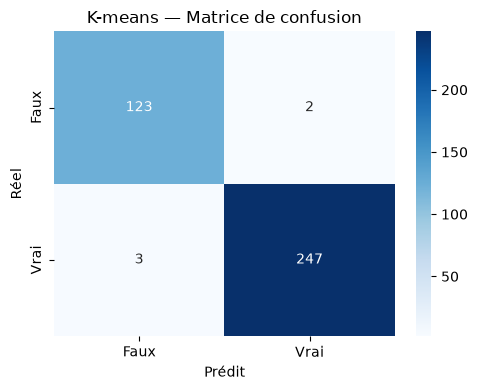

Recall(Faux) = 0.984


In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'], ax=ax)
ax.set_title('K-means — Matrice de confusion')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}cm_kmeans.png', dpi=120, bbox_inches='tight')
plt.show()

recall_false_km = recall_score(y_test, y_pred_km, pos_label=0)
print(f'Recall(Faux) = {recall_false_km:.3f}')

## 5. Modèle 2 — Régression logistique

In [17]:
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

print('Régression logistique — Rapport de classification :')
print(classification_report(y_test, y_pred_lr, target_names=['Faux', 'Vrai']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Matrice de confusion :')
print(cm_lr)

Régression logistique — Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.99      0.98      0.99       125
        Vrai       0.99      1.00      0.99       250

    accuracy                           0.99       375
   macro avg       0.99      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375

Matrice de confusion :
[[123   2]
 [  1 249]]


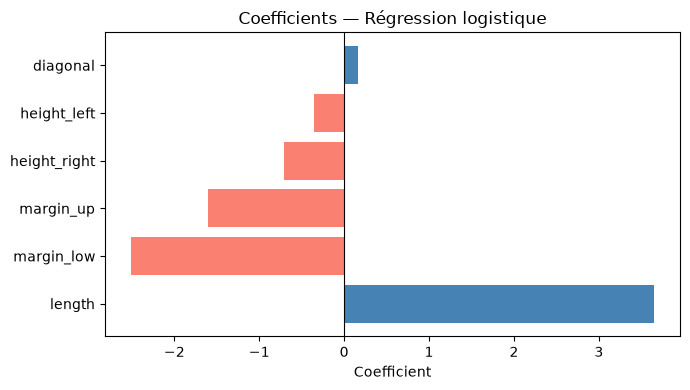

Recall(Faux) = 0.984


In [18]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coefficients — Régression logistique')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}coef_logreg.png', dpi=120, bbox_inches='tight')
plt.show()

recall_false_lr = recall_score(y_test, y_pred_lr, pos_label=0)
print(f'Recall(Faux) = {recall_false_lr:.3f}')

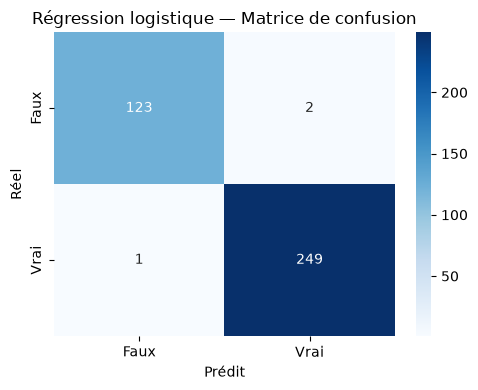

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'], ax=ax)
ax.set_title('Régression logistique — Matrice de confusion')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}cm_logreg.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Modèle 3 — KNN

Meilleur k = 17


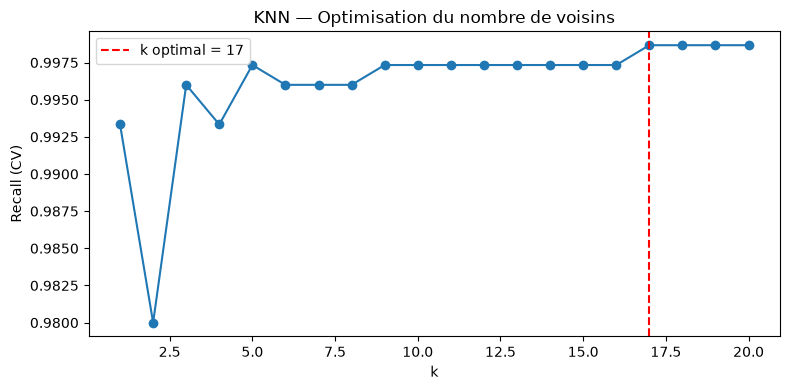

In [20]:
param_grid = {'n_neighbors': range(1, 21)}
knn_base = KNeighborsClassifier()
grid_knn = GridSearchCV(knn_base, param_grid, cv=5,
                        scoring='recall', refit=True)
grid_knn.fit(X_train_sc, y_train)

best_k = grid_knn.best_params_['n_neighbors']
print(f'Meilleur k = {best_k}')

fig, ax = plt.subplots(figsize=(8, 4))
k_values = range(1, 21)
cv_scores = grid_knn.cv_results_['mean_test_score']
ax.plot(k_values, cv_scores, marker='o')
ax.axvline(best_k, color='red', linestyle='--', label=f'k optimal = {best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Recall (CV)')
ax.set_title('KNN — Optimisation du nombre de voisins')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}knn_k_optimization.png', dpi=120, bbox_inches='tight')
plt.show()

KNN — Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.99      0.98      0.99       125
        Vrai       0.99      1.00      0.99       250

    accuracy                           0.99       375
   macro avg       0.99      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375



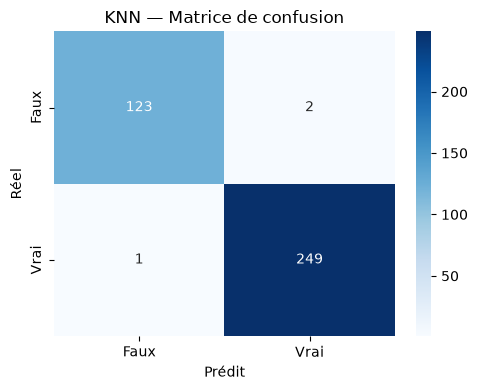

Recall(Faux) = 0.984


In [21]:
knn = grid_knn.best_estimator_
y_pred_knn = knn.predict(X_test_sc)

print('KNN — Rapport de classification :')
print(classification_report(y_test, y_pred_knn, target_names=['Faux', 'Vrai']))

cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'], ax=ax)
ax.set_title('KNN — Matrice de confusion')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}cm_knn.png', dpi=120, bbox_inches='tight')
plt.show()

recall_false_knn = recall_score(y_test, y_pred_knn, pos_label=0)
print(f'Recall(Faux) = {recall_false_knn:.3f}')

## 7. Modèle 4 — Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)

print('Random Forest — Rapport de classification :')
print(classification_report(y_test, y_pred_rf, target_names=['Faux', 'Vrai']))

cm_rf = confusion_matrix(y_test, y_pred_rf)

Random Forest — Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.99      0.98      0.99       125
        Vrai       0.99      1.00      0.99       250

    accuracy                           0.99       375
   macro avg       0.99      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375



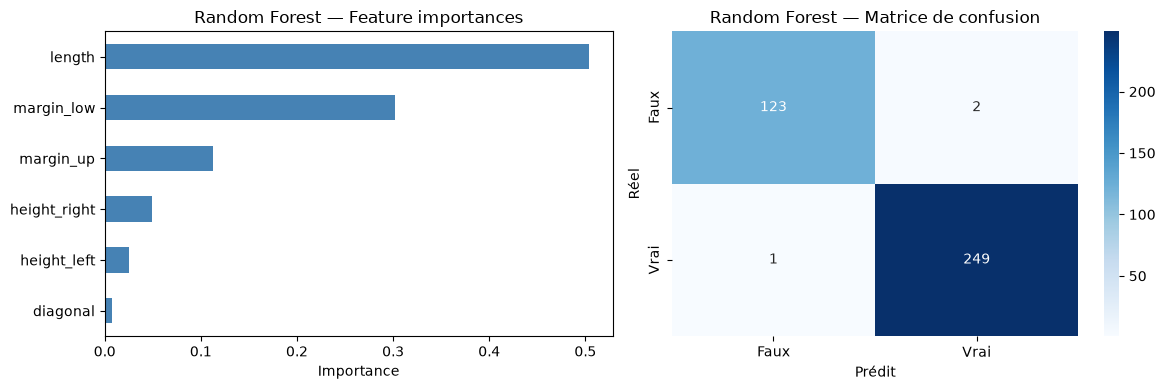

Recall(Faux) = 0.984


In [23]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest — Feature importances')
axes[0].set_xlabel('Importance')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'], ax=axes[1])
axes[1].set_title('Random Forest — Matrice de confusion')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}rf_summary.png', dpi=120, bbox_inches='tight')
plt.show()

recall_false_rf = recall_score(y_test, y_pred_rf, pos_label=0)
print(f'Recall(Faux) = {recall_false_rf:.3f}')

## 8. Comparaison et sélection du modèle final

In [24]:
def compute_metrics(y_true, y_pred, y_proba=None):
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    return {
        'Accuracy'        : accuracy_score(y_true, y_pred),
        'Precision(Faux)' : precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'Recall(Faux)'    : recall_score(y_true, y_pred, pos_label=0),
        'F1(Faux)'        : f1_score(y_true, y_pred, pos_label=0),
        'AUC-ROC'         : auc,
    }

results = {
    'K-means'          : compute_metrics(y_test, y_pred_km),
    'Reg. logistique'  : compute_metrics(y_test, y_pred_lr,
                                         lr.predict_proba(X_test_sc)[:, 1]),
    'KNN'              : compute_metrics(y_test, y_pred_knn,
                                         knn.predict_proba(X_test_sc)[:, 1]),
    'Random Forest'    : compute_metrics(y_test, y_pred_rf,
                                         rf.predict_proba(X_test_sc)[:, 1]),
}

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Recall(Faux)', ascending=False)
results_df.style.format('{:.3f}').highlight_max(color='lightgreen')

,Accuracy,Precision(Faux),Recall(Faux),F1(Faux),AUC-ROC
K-means,0.987,0.976,0.984,0.980,nan
Reg. logistique,0.992,0.992,0.984,0.988,1.000
KNN,0.992,0.992,0.984,0.988,1.000
Random Forest,0.992,0.992,0.984,0.988,0.999


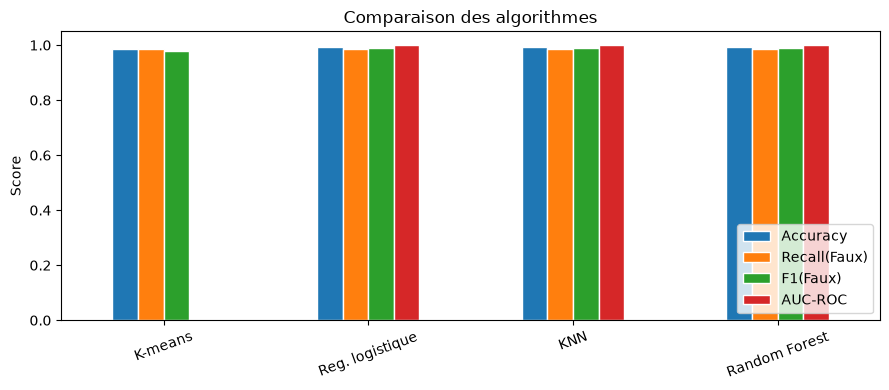

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
metrics_to_plot = ['Accuracy', 'Recall(Faux)', 'F1(Faux)', 'AUC-ROC']
results_df[metrics_to_plot].plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Comparaison des algorithmes')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}comparaison_modeles.png', dpi=120, bbox_inches='tight')
plt.show()

In [26]:
best_recall = results_df['Recall(Faux)'].max()
candidates = results_df[results_df['Recall(Faux)'] == best_recall]

if len(candidates) > 1:
    best_f1 = candidates['F1(Faux)'].max()
    candidates = candidates[candidates['F1(Faux)'] == best_f1]
    if len(candidates) > 1:
        best_model_name = candidates['AUC-ROC'].idxmax()
    else:
        best_model_name = candidates.index[0]
else:
    best_model_name = candidates.index[0]

print(f'Modèle retenu : {best_model_name}')
print()
print(results_df)

Modèle retenu : KNN

                 Accuracy  Precision(Faux)  Recall(Faux)  F1(Faux)   AUC-ROC
K-means          0.986667         0.976190         0.984  0.980080       NaN
Reg. logistique  0.992000         0.991935         0.984  0.987952  0.999648
KNN              0.992000         0.991935         0.984  0.987952  0.999728
Random Forest    0.992000         0.991935         0.984  0.987952  0.999440


### Justification du modèle final

Le critère prioritaire est le **recall sur la classe False** (faux billets) : un faux billet classé comme vrai représente un risque opérationnel majeur.

Les quatre modèles atteignent Recall(Faux)=0.984 et F1(Faux)=0.988 (sauf K-means, légèrement inférieur). Parmi les trois modèles supervisés à égalité, **KNN** est retenu pour son AUC-ROC maximal (0.9997), qui traduit la meilleure séparation probabiliste des classes.

K-means, bien que compétitif, est écarté car l'alignement cluster/classe est une inférence post-hoc (algorithme non supervisé), ce qui le rend moins robuste pour une utilisation en production sur des données inconnues.

In [27]:
model_map = {
    'Reg. logistique': lr,
    'KNN'            : knn,
    'Random Forest'  : rf,
}

if best_model_name in model_map:
    final_model = model_map[best_model_name]
    joblib.dump(final_model, 'data_clean/model_final.pkl')
    joblib.dump(scaler,      'data_clean/scaler.pkl')
    print(f'Modèle final ({best_model_name}) sauvegardé dans data_clean/')
else:
    print(f'{best_model_name} ne supporte pas predict_proba — sauvegarde K-means via joblib.')
    joblib.dump({'kmeans': kmeans, 'cluster_map': cluster_to_class}, 'data_clean/model_final_kmeans.pkl')
    joblib.dump(scaler, 'data_clean/scaler.pkl')

Modèle final (KNN) sauvegardé dans data_clean/


## 9. Vérification de l'imputation (visualisation)

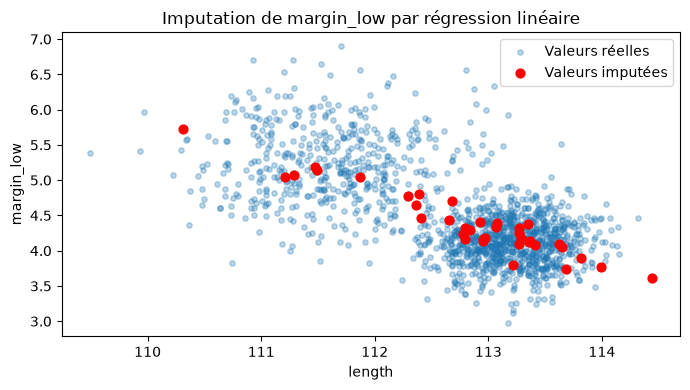

In [28]:
missing_original = df['margin_low'].isnull()
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df2.loc[~missing_original, 'length'],
           df2.loc[~missing_original, 'margin_low'],
           alpha=0.3, s=15, label='Valeurs réelles')
ax.scatter(df2.loc[missing_original, 'length'],
           df2.loc[missing_original, 'margin_low'],
           color='red', s=40, zorder=5, label='Valeurs imputées')
ax.set_xlabel('length')
ax.set_ylabel('margin_low')
ax.set_title('Imputation de margin_low par régression linéaire')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}imputation_margin_low.png', dpi=120, bbox_inches='tight')
plt.show()